In [ ]:
%load_ext autoreload
%autoreload 2

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
assert os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] == "false"

import sys
sys.path.append('../')
sys.path.append('../../')

import ATLAS

import json, pickle
from glob import glob
from tqdm import tqdm

import numpy as np
from matplotlib import pyplot as plt


ideal_path = '../../datasets/ideal_NG15'

In [ ]:
def get_name(parOrTim):
    return parOrTim.split('/')[-1].split('_')[0]

def get_partim(path):
    parfiles = sorted(glob(f'{path}/par/*.par'))
    timfiles = sorted(glob(f'{path}/tim/*.tim'))
    assert len(parfiles) == len(timfiles)
    for p,t in zip(parfiles, timfiles):
        assert get_name(p) == get_name(t), f'{p, t}'
    return parfiles, timfiles

def parse_par(parfile):
    with open(parfile, 'r') as f:
        lines = f.readlines()

    params = {}
    for l in lines:
        if l.startswith('#'):
            continue # Comment line

        parts = l.split() # This removes spaces as well
        if '1' in parts:
            # Fitted parameter
            idx = parts.index('1')
            key = ' '.join(parts[:idx-1])
            value = float(parts[idx-1])
            error = float(parts[idx+1])
            params[key] = (value, error)

        else:
            key = ' '.join(parts[:-1])
            value = parts[-1]
            try:
                value = float(value)
            except:
                pass
            params[key] = (value, None)

    return params



m2_loc, m2_scale = 0.214, 0.25
a, b = (-m2_loc/m2_scale), (1-m2_loc)/m2_scale
from scipy.stats import norm, uniform, truncnorm, loguniform
binary_priors = {
    'BINARY':   None, # No vary             # Binary timing model (DD, DDK, BT, ELL1, ELL1H)
    'PB':       uniform(0.05, 500),         # Orbital period (days)
    'PBDOT':    uniform(-1e-10, 1e-10),     # Time derivative of orbital period
    'A1':       uniform(0, 150),            # Projected semi-major axis (light-seconds)
    'A1DOT':    uniform(-1e-10, 1e-10),     # Time derivative of A1
    '_DT0':     uniform(-1, 1),             # delta of T0 (MJD)
    'T0':       None, # Use _DT0 to derive  # Epoch of periastron passage (MJD)
    '_DTASC':   uniform(-1, 1),             # delta of TASC (MJD)
    'TASC':     None,                       # Epoch of ascending node passage (MJD)
    'ECC':      uniform(0, 1),              # Orbital eccentricity
    'EDOT':     uniform(-1e-10, 0),         # Time derivative of eccentricity
    'OM':       uniform(-360, 360),         # Longitude of periastron (deg)
    'OMDOT':    uniform(-3, 3),             # Time derivative of OM
    'EPS1':     uniform(-1, 1),             # Laplace-Lagrange parameter e*sin(omega)
    'EPS2':     uniform(-1, 1),             # Laplace-Lagrange parameter e*cos(omega)
    '_COSI':    uniform(0, 1),              # cos(inclination) [Used to derive SINI]
    'SINI':     None, # Use _COSI to derive # sin(inclination)
    'M2':       truncnorm(a, b,             # Companion mass (solar masses)
                loc=m2_loc, scale=m2_scale),
    'KIN':      uniform(0, 360),            # Inclination angle (deg), used by DDK
    'KOM':      uniform(-180, 180),         # Longitude of ascending node (deg), used by DDK
    'GAMMA':    None, # No vary             # Einstein delay parameter
    'A0':       None, # No vary             # Aberration parameter A0
    'B0':       None, # No vary             # Aberration parameter B0
    'DR':       None, # No vary             # Damour-Deruelle parameter dr
    'DTH':      None, # No vary             # Damour-Deruelle parameter dtheta
    'H3':       uniform(-1e-6, 1e-6),       # Orthometric Shapiro delay amplitude
    'NHARMS':   None, # No vary             # Number of harmonics (ELL1H)
    'FB0':      uniform(0, 1),              # Orbital frequency and derivatives (ELL1)
    'FB1':      uniform(-1e-15, 1e-15),     
    'FB2':      uniform(-1e-15, 1e-15),
    'FB3':      uniform(-1e-15, 1e-15),
    'FB4':      uniform(-1e-15, 1e-15),
    'FB5':      uniform(-1e-15, 1e-15),
}


def get_binary_params(par_dict):
    return {k: v for k, v in par_dict.items() if k in binary_priors.keys()}




3
-1.2542577204288636e-19 3.827251866515394e-20


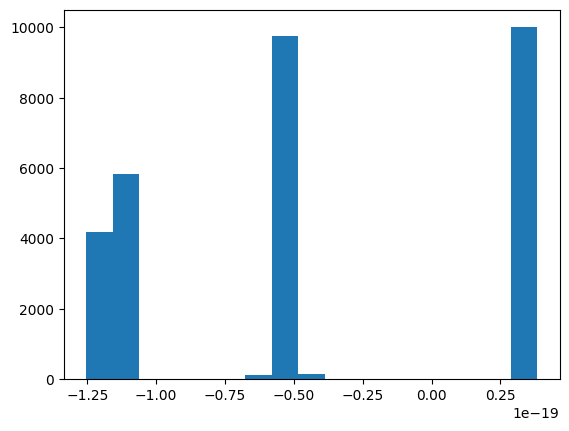

In [70]:
par, tim = get_partim(ideal_path)
params = [parse_par(p) for p in par]

to_get = 'FB1'
vals, errs = [], []
for p in params:
    if (to_get in p) and (p[to_get][1] is not None):
        vals.append(p[to_get][0])
        errs.append(p[to_get][1])

print(len(vals))

# Do some uncertainty sampling-like stuff
comb = np.reshape([np.random.normal(v,e, size=10000) for v,e in zip(vals, errs)], (-1,))
print(min(comb), max(comb))
plt.hist(comb, bins='auto')
plt.show()